# Анализ влияния игр на продуктивность

## 1. Загрузка и обзор данных

### 1.1. Импорт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2. Первичный просмотр данных

Загрузка датасета:

In [2]:
original_df = pd.read_csv('gaming_productivity_dataset.csv')
df = original_df.copy()

Размер датасета (строки, столбцы):

In [3]:
df.shape

(1000, 14)

Краткая информация о датасете:

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   User_ID                 1000 non-null   object 
 1   Age                     1000 non-null   int64  
 2   Gender                  1000 non-null   object 
 3   Occupation              1000 non-null   object 
 4   Game_Type               1000 non-null   object 
 5   Daily_Gaming_Hours      1000 non-null   float64
 6   Weekly_Gaming_Hours     1000 non-null   float64
 7   Primary_Gaming_Time     1000 non-null   object 
 8   Sleep_Hours             1000 non-null   float64
 9   Stress_Level            1000 non-null   int64  
 10  Focus_Level             1000 non-null   int64  
 11  Academic_or_Work_Score  1000 non-null   int64  
 12  Productivity_Level      1000 non-null   int64  
 13  Performance_Impact      1000 non-null   object 
dtypes: float64(3), int64(5), object(6)
memory

Первые и последние 10 строк:

In [5]:
df.head(10)

,User_ID,Age,Gender,Occupation,Game_Type,Daily_Gaming_Hours,Weekly_Gaming_Hours,Primary_Gaming_Time,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level,Performance_Impact
0,U0001,21,Male,Working Professional,Action,4.0,28.0,Morning,4.6,6,4,69,66,Negative
1,U0002,35,Female,Student,Sports,1.0,7.0,Night,5.4,2,7,67,72,Neutral
2,U0003,26,Male,Student,Puzzle,2.0,14.0,Morning,8.0,4,8,82,82,Positive
3,U0004,32,Male,Working Professional,Action,1.0,7.0,Night,4.9,7,7,71,66,Neutral
4,U0005,19,Male,Working Professional,Action,2.1,14.7,Morning,7.0,7,7,67,63,Neutral
5,U0006,29,Female,Student,Casual,5.3,37.1,Evening,6.0,9,8,78,75,Neutral
6,U0007,35,Male,Student,Sports,4.4,30.8,Evening,7.2,3,7,95,92,Neutral
7,U0008,25,Male,Working Professional,Sports,2.0,14.0,Evening,8.2,5,8,75,70,Positive
8,U0009,32,Male,Working Professional,Strategy,0.9,6.3,Morning,8.2,7,4,86,87,Positive
9,U0010,25,Male,Working Professional,Action,4.6,32.2,Morning,6.7,8,7,80,80,Neutral


In [19]:
df.tail(10)

,User_ID,Age,Gender,Occupation,Game_Type,Daily_Gaming_Hours,Weekly_Gaming_Hours,Primary_Gaming_Time,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level,Performance_Impact
990,U0991,35,Male,Working Professional,Simulation,1.0,7.0,Night,4.6,8,3,86,90,Neutral
991,U0992,35,Female,Student,Strategy,4.9,34.3,Evening,7.2,8,4,69,71,Neutral
992,U0993,29,Male,Working Professional,Puzzle,5.7,39.9,Night,5.9,9,6,80,75,Negative
993,U0994,31,Male,Student,Action,2.0,14.0,Morning,7.9,8,8,70,65,Positive
994,U0995,31,Male,Working Professional,Strategy,4.8,33.6,Night,7.9,7,5,65,69,Neutral
995,U0996,23,Female,Working Professional,Simulation,4.0,28.0,Morning,7.8,8,4,95,96,Neutral
996,U0997,30,Female,Student,Puzzle,2.9,20.3,Morning,4.9,4,7,62,67,Neutral
997,U0998,18,Male,Working Professional,Action,1.0,7.0,Night,4.6,2,8,92,89,Neutral
998,U0999,25,Female,Student,Simulation,4.5,31.5,Morning,8.4,7,4,70,75,Neutral
999,U1000,19,Female,Student,Strategy,4.5,31.5,Night,7.7,8,9,71,76,Neutral


Основная статистика:

In [6]:
df.describe()

,Age,Daily_Gaming_Hours,Weekly_Gaming_Hours,Sleep_Hours,Stress_Level,Focus_Level,Academic_or_Work_Score,Productivity_Level
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,26.600000,3.320300,23.242100,6.479500,5.454000,6.065000,75.07800,75.275000
std,5.207218,1.613059,11.291414,1.155848,2.281905,2.010178,11.67494,12.058805
min,18.000000,0.500000,3.500000,4.500000,2.000000,3.000000,55.00000,50.000000
25%,22.000000,2.000000,14.000000,5.475000,3.000000,4.000000,65.00000,65.000000
50%,27.000000,3.300000,23.100000,6.500000,5.000000,6.000000,75.00000,75.000000
75%,31.000000,4.800000,33.600000,7.500000,7.000000,8.000000,85.00000,86.000000
max,35.000000,6.000000,42.000000,8.500000,9.000000,9.000000,95.00000,100.000000


Название всех столбцов:

In [7]:
print(list(df.columns))

['User_ID', 'Age', 'Gender', 'Occupation', 'Game_Type', 'Daily_Gaming_Hours', 'Weekly_Gaming_Hours', 'Primary_Gaming_Time', 'Sleep_Hours', 'Stress_Level', 'Focus_Level', 'Academic_or_Work_Score', 'Productivity_Level', 'Performance_Impact']


# 2. Предобработка данных

## 2.1. Проверка на наличие пропусков

In [8]:
df.isnull().sum()

User_ID                   0
Age                       0
Gender                    0
Occupation                0
Game_Type                 0
Daily_Gaming_Hours        0
Weekly_Gaming_Hours       0
Primary_Gaming_Time       0
Sleep_Hours               0
Stress_Level              0
Focus_Level               0
Academic_or_Work_Score    0
Productivity_Level        0
Performance_Impact        0
dtype: int64

## 2.2. Проверка наличия дубликатов

Полные дубликаты строк:

In [9]:
df.duplicated().sum()

np.int64(0)

Дубликаты столбца User_ID:

In [10]:
df['User_ID'].duplicated().sum()

np.int64(0)

## 2.3. Проверка наличия уникальных значений

Проверка уникальных ID:

In [11]:
df['User_ID'].nunique()

1000

## 2.4. Анализ распределения

Анализ распределения числовых столбцов:

In [12]:
numeric_cols = ['Age', 'Daily_Gaming_Hours', 'Sleep_Hours', 
                'Stress_Level', 'Focus_Level', 'Academic_or_Work_Score']

for col in numeric_cols:
    print(f"{col}: Mean={df[col].mean():.2f}, Median={df[col].median():.2f}, "
          f"Skew={df[col].skew():.3f}")

Age: Mean=26.60, Median=27.00, Skew=-0.016
Daily_Gaming_Hours: Mean=3.32, Median=3.30, Skew=-0.049
Sleep_Hours: Mean=6.48, Median=6.50, Skew=0.032
Stress_Level: Mean=5.45, Median=5.00, Skew=0.026
Focus_Level: Mean=6.07, Median=6.00, Skew=-0.065
Academic_or_Work_Score: Mean=75.08, Median=75.00, Skew=0.019


Визуализация столбцов:

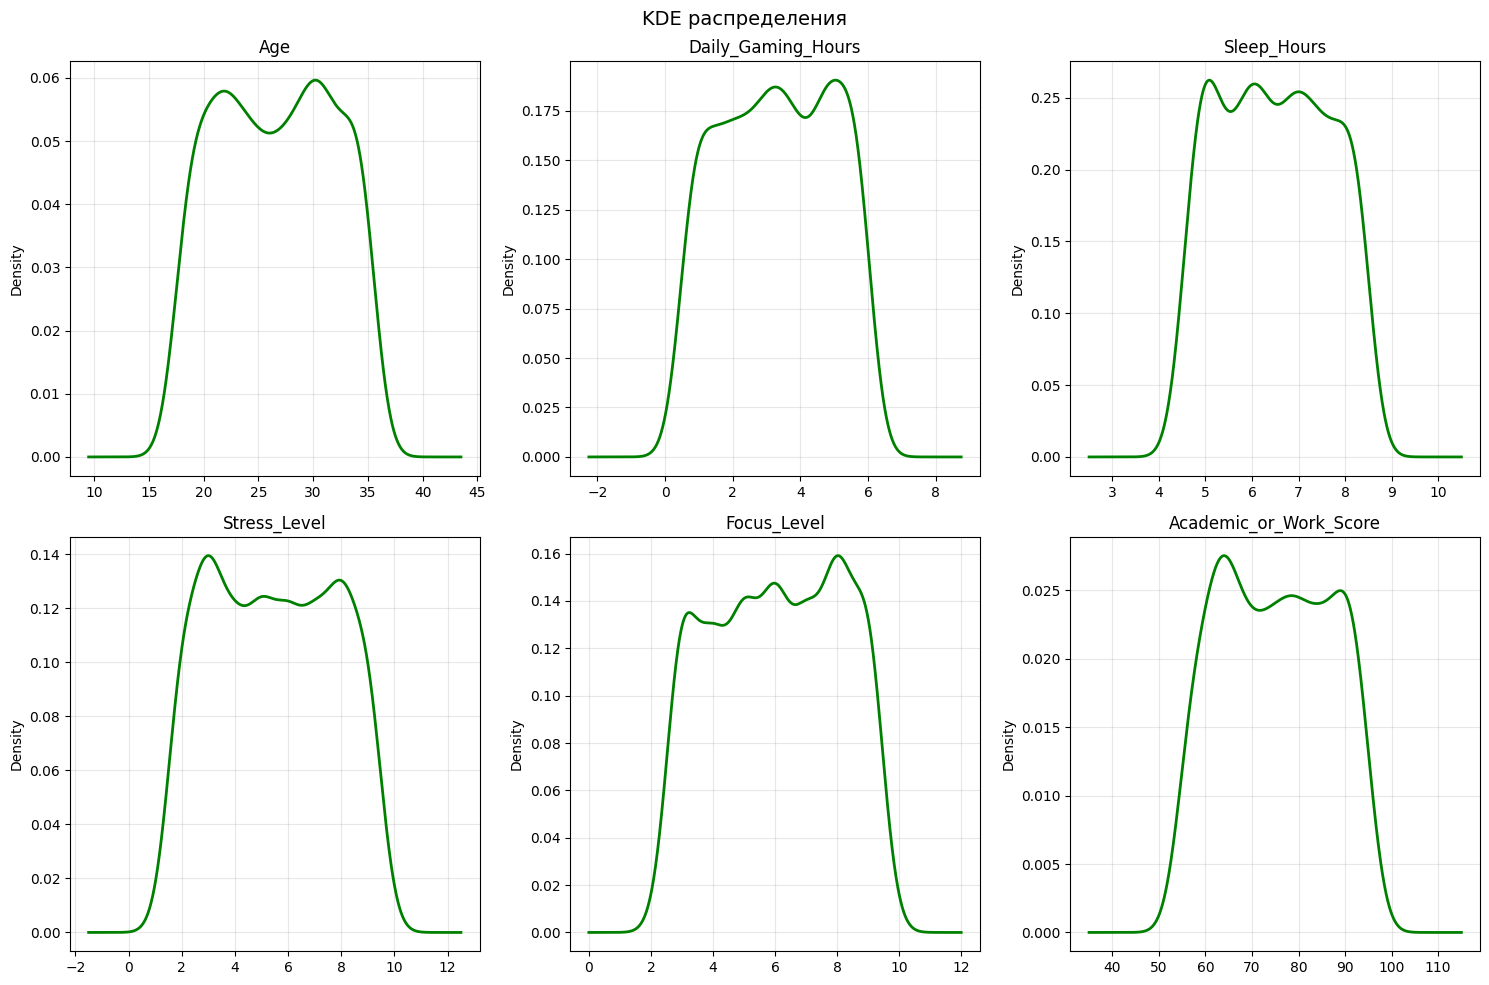

In [13]:
cols = ['Age', 'Daily_Gaming_Hours', 'Sleep_Hours', 
        'Stress_Level', 'Focus_Level', 'Academic_or_Work_Score']

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    
    df[col].plot.kde(color='green', linewidth=2)
    
    plt.title(col)
    plt.xlabel('')
    plt.grid(True, alpha=0.3)

plt.suptitle('KDE распределения', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
for col in ['Daily_Gaming_Hours', 'Stress_Level', 'Sleep_Hours', 'Academic_or_Work_Score']:
    student_mean = df[df['Age'] < 25][col].mean()
    worker_mean = df[df['Age'] > 28][col].mean()
    
    diff_percent = ((student_mean - worker_mean) / worker_mean) * 100
    print(f"{col}: студенты vs работающие = {diff_percent:+.1f}% разницы")

Daily_Gaming_Hours: студенты vs работающие = -5.9% разницы
Stress_Level: студенты vs работающие = +3.1% разницы
Sleep_Hours: студенты vs работающие = +1.1% разницы
Academic_or_Work_Score: студенты vs работающие = +0.4% разницы


## 2.5. Анализ выбросов

Анализ выбросов методом IQR между ключевыми столбцами:

In [15]:
numeric_cols = ['Age', 'Daily_Gaming_Hours', 'Sleep_Hours', 
                'Stress_Level', 'Focus_Level', 'Academic_or_Work_Score']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_percent = len(outliers) / len(df) * 100

    print(f"  Границы: [{lower_bound:.1f}, {upper_bound:.1f}]")
    print(f"  Мин и макс: [{df[col].min():.1f}, {df[col].max():.1f}]")
    print(f"  Выбросов: {len(outliers)} ({outlier_percent:.1f}%)")

  Границы: [8.5, 44.5]
  Мин и макс: [18.0, 35.0]
  Выбросов: 0 (0.0%)
  Границы: [-2.2, 9.0]
  Мин и макс: [0.5, 6.0]
  Выбросов: 0 (0.0%)
  Границы: [2.4, 10.5]
  Мин и макс: [4.5, 8.5]
  Выбросов: 0 (0.0%)
  Границы: [-3.0, 13.0]
  Мин и макс: [2.0, 9.0]
  Выбросов: 0 (0.0%)
  Границы: [-2.0, 14.0]
  Мин и макс: [3.0, 9.0]
  Выбросов: 0 (0.0%)
  Границы: [35.0, 115.0]
  Мин и макс: [55.0, 95.0]
  Выбросов: 0 (0.0%)


Вывод: Выбросы отсуствуют. 
- Все значения находятся в пределах нормы.
- Процент выбросов по каждой переменной: 0%
- Данные не требуют обработки выбросов
- Можно использовать все наблюдения без исключений
- Параметрические методы статистики применимы без ограничений

# 3. Анализ взаимосвязей

## 3.1. Исходные гипотезы исследования

1. Существует отрицательная корреляция между Daily_Gaming_Hours и Academic_or_Work_Score
2. Уровень стресса положительно коррелирует с игровым временем
3. Продолжительность сна отрицательно коррелирует с игровым временем
4. Студенты проводят за играми больше времени, чем работающие профессионалы

## 3.2. Матрица корреляции

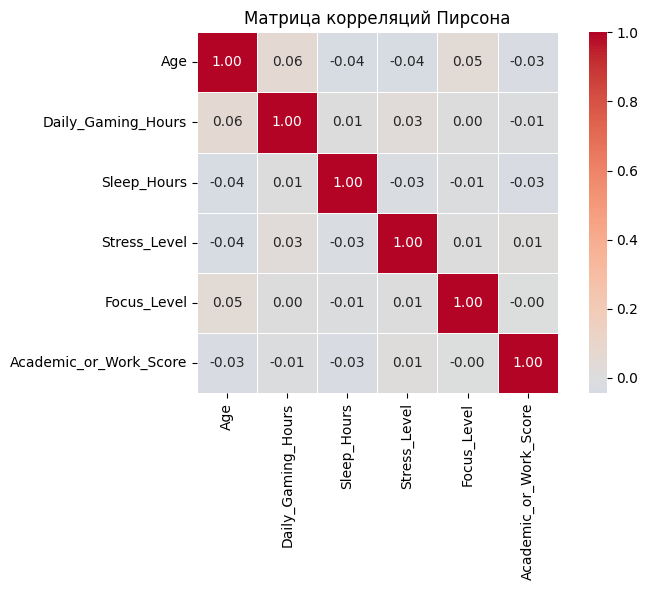

In [16]:
corr_columns = ['Age', 'Daily_Gaming_Hours', 
                'Sleep_Hours', 'Stress_Level', 
                'Focus_Level', 'Academic_or_Work_Score']

corr_matrix = df[corr_columns].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Матрица корреляций Пирсона')
plt.tight_layout()
plt.show()

Обнаружена практически полная корреляция (r=0.965) между Academic_or_Work_Score и Productivity_Level, при этом обе переменные измеряются в одной шкале (0-100 баллов). Это указывает на дублирование информации в датасете. Для дальнейшего анализа оставлена переменная Academic_or_Work_Score.

Удаление столбцов:

In [17]:
df_clean = df.drop(columns=['Productivity_Level', 'Weekly_Gaming_Hours'])

Выводы по корреляционному анализу.

1. **Отсутствуют линейные связи**:
- Между игровым временем (Daily_Gaming_Hours) и академическими, рабочими оценками (Academic_or_Work_Score) корреляция практически нулевая (r ≈ 0.01)
- Уровень стресса, продолжительность сна и концентрация также не демонстрируют значимых линейных связей с успеваемостью

2. **Обнаруженные проблемы данных**:
- Выявлена мультиколлинеарность: Weekly_Gaming_Hours полностью дублирует Daily_Gaming_Hours (r = 1.00)
- Переменные Academic_or_Work_Score и Productivity_Level измеряют одно явление (r = 0.965)

3. **Следствия для дальнейшего анализа**:
- Удалены избыточные переменные (Weekly_Gaming_Hours, Productivity_Level)
- Основная гипотеза исследования (влияние игр на продуктивность) не подтверждается линейными методами
- Требуется применение нелинейных подходов или анализ скрытых факторов

## 3.3. Визуализация парных зависсимостей

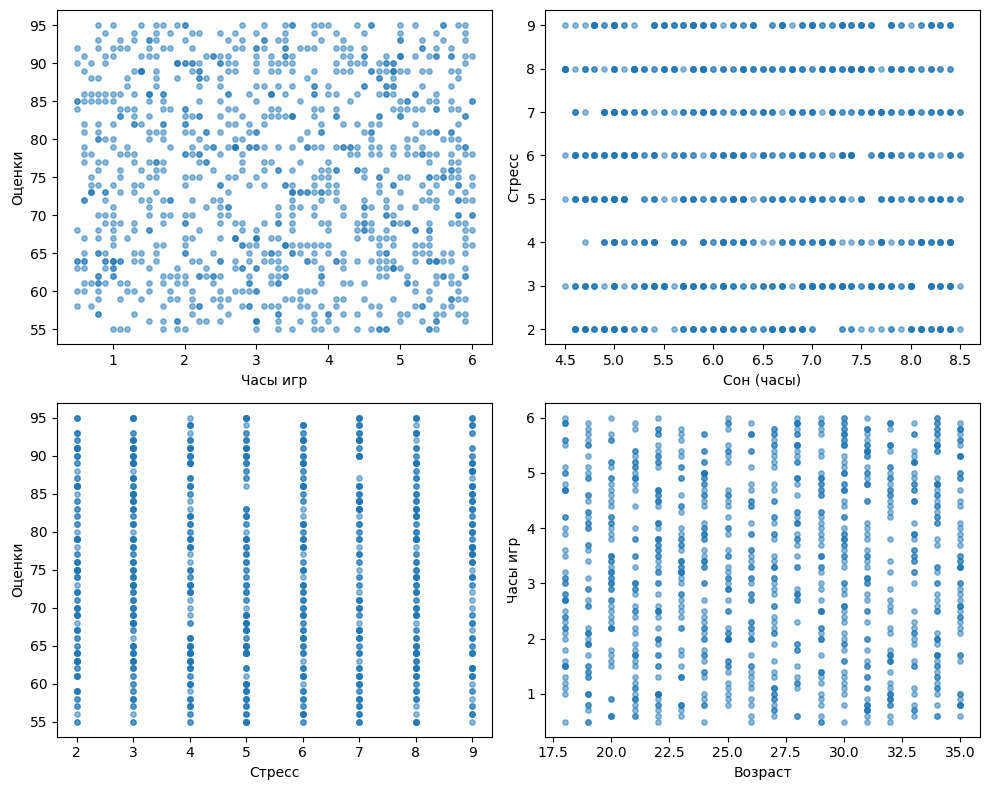

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# 1. Игры vs Оценки
axes[0,0].scatter(df['Daily_Gaming_Hours'], df['Academic_or_Work_Score'], alpha=0.5, s=15)
axes[0,0].set_xlabel('Часы игр')
axes[0,0].set_ylabel('Оценки')

# 2. Сон vs Стресс
axes[0,1].scatter(df['Sleep_Hours'], df['Stress_Level'], alpha=0.5, s=15)
axes[0,1].set_xlabel('Сон (часы)')
axes[0,1].set_ylabel('Стресс')

# 3. Стресс vs Оценки
axes[1,0].scatter(df['Stress_Level'], df['Academic_or_Work_Score'], alpha=0.5, s=15)
axes[1,0].set_xlabel('Стресс')
axes[1,0].set_ylabel('Оценки')

# 4. Возраст vs Игры
axes[1,1].scatter(df['Age'], df['Daily_Gaming_Hours'], alpha=0.5, s=15)
axes[1,1].set_xlabel('Возраст')
axes[1,1].set_ylabel('Часы игр')

plt.tight_layout()
plt.show()

Визуальный анализ scatter plots подтвердил отсутствие линейных зависимостей между ключевыми переменными. Облака точек не демонстрируют каких-либо направленных трендов, что согласуется с результатами корреляционного анализа.

## 3.4. Результаты проверки гипотез

Гипотеза 1 не подтвердилась
Отрицательной корреляции между игровым временем и оценками не обнаружено (r ≈ 0). Визуальный анализ также не выявил зависимости.

Гипотеза 2 не подтвердилась
Уровень стресса не коррелирует с игровым временем (r = 0.03).

Гипотеза 3 не подтвердилась
Продолжительность сна не связана с игровым временем (r = 0.01).

Гипотеза 4 не подтвердилась
Студенты (22 года) играют меньше (на 5.9%), чем работающие профессионалы (30 лет).

# 4. Демографический и поведенческий анализ

## 4.1. Распределение по полу и его влияние на показатели

Распределение по полам:

In [ ]:
gender_counts = df['Gender'].value_counts()
print(gender_counts)

Gender
Female    513
Male      487
Name: count, dtype: int64
[513 487]


Визуализация распределения:

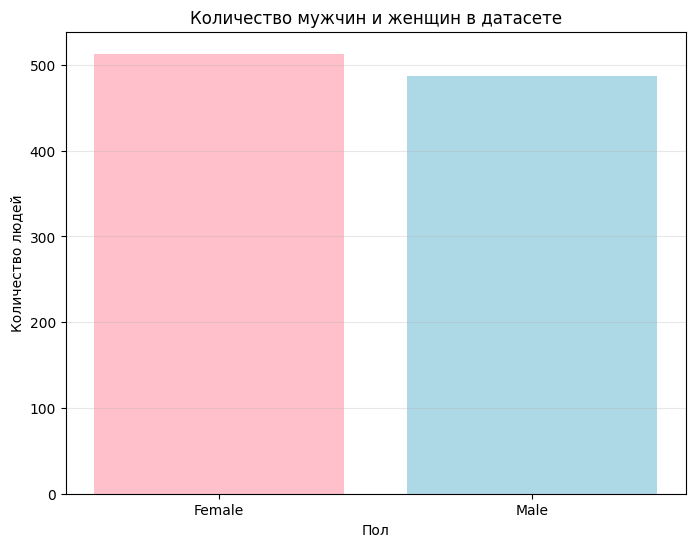

In [32]:
plt.figure(figsize=(8, 6))
plt.bar(gender_counts.index, gender_counts.values, color=['pink', 'lightblue'])
plt.title('Количество мужчин и женщин в датасете')
plt.ylabel('Количество людей')
plt.xlabel('Пол')
plt.grid(axis='y', alpha=0.3)
plt.show()

Сравнение средних показателей:

In [29]:
gender_stats = df.groupby('Gender').agg({
    'Daily_Gaming_Hours': 'mean',
    'Academic_or_Work_Score': 'mean', 
    'Stress_Level': 'mean',
    'Sleep_Hours': 'mean'
})

print(gender_stats)

        Daily_Gaming_Hours  Academic_or_Work_Score  Stress_Level  Sleep_Hours
Gender                                                                       
Female            3.407212               75.335283      5.547758     6.438402
Male              3.228747               74.806982      5.355236     6.522793


Визуализация показателей:

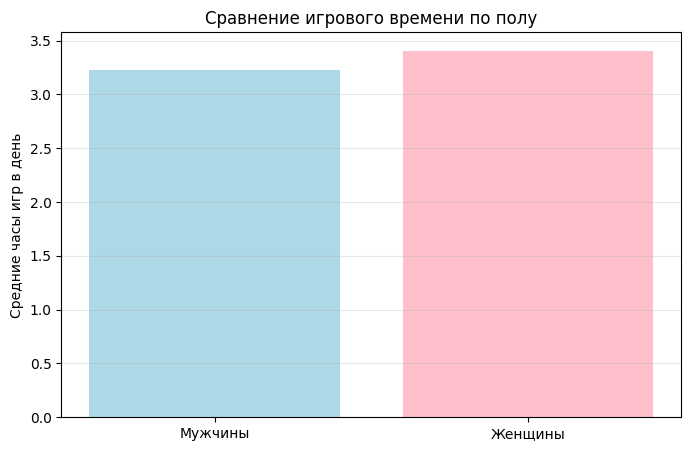

In [31]:
male_gaming = df[df['Gender']=='Male']['Daily_Gaming_Hours'].mean()
female_gaming = df[df['Gender']=='Female']['Daily_Gaming_Hours'].mean()

plt.figure(figsize=(8, 5))
plt.bar(['Мужчины', 'Женщины'], [male_gaming, female_gaming], 
        color=['lightblue', 'pink'])
plt.ylabel('Средние часы игр в день')
plt.title('Сравнение игрового времени по полу')
plt.grid(axis='y', alpha=0.3)
plt.show()

Вывод: Женщины играют в среднем 3.4 часа в день, мужчины - 3.2 часа. Разница составляет 0.2 часа (6%). Небольшое численное преимущество может объясняться преобладанием женщин в выборке (513 женщин против 487 мужчин).

## 4.2. Сравнение студентов и работающих профессионалов

Распределение по роду занятий:

In [34]:
occupation_count = df['Occupation'].value_counts()
print(occupation_count)

Occupation
Student                 524
Working Professional    476
Name: count, dtype: int64


Сравнение средних показателей:

In [35]:
occupation_stats = df.groupby('Occupation').agg({
    'Daily_Gaming_Hours': 'mean',
    'Academic_or_Work_Score': 'mean',
    'Stress_Level': 'mean',
    'Sleep_Hours': 'mean',
    'Focus_Level': 'mean'
})
print(occupation_stats)

                      Daily_Gaming_Hours  Academic_or_Work_Score  \
Occupation                                                         
Student                         3.245611               75.452290   
Working Professional            3.402521               74.665966   

                      Stress_Level  Sleep_Hours  Focus_Level  
Occupation                                                    
Student                   5.419847     6.460496     6.116412  
Working Professional      5.491597     6.500420     6.008403  


Визуализация показателей:

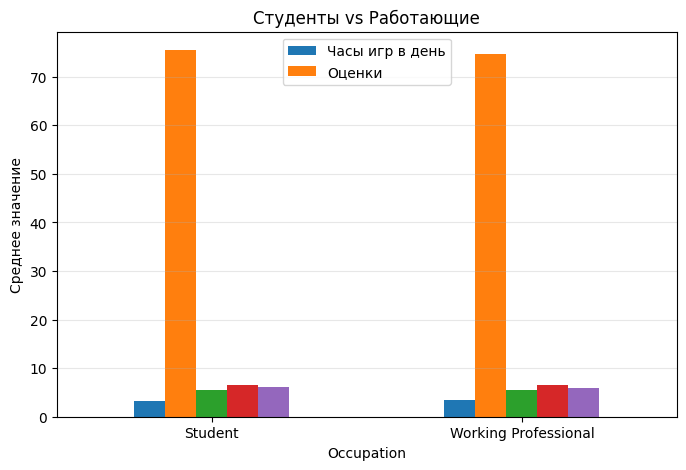

In [38]:
occupation_stats.plot(kind='bar', figsize=(8, 5))
plt.title('Студенты vs Работающие')
plt.ylabel('Среднее значение')
plt.xticks(rotation=0)
plt.legend(['Часы игр в день', 'Оценки'])
plt.grid(axis='y', alpha=0.3)
plt.show()

Вывод: Вопреки ожиданиям, работающие профессионалы тратят на игры немного больше времени, чем студенты (3.40 ч vs 3.25 ч), однако показывают несколько более низкие оценки продуктивности (74.67 vs 75.45 баллов). Различия статистически незначимы и составляют менее 1%, что указывает на схожие паттерны поведения в обеих группах.

## 4.3. Анализ игровых привычек по времени суток

Распределение:

In [39]:
time_counts = df['Primary_Gaming_Time'].value_counts()
print(time_counts)

Primary_Gaming_Time
Morning    341
Evening    338
Night      321
Name: count, dtype: int64


Сравнение показателей:

In [40]:
time_stats = df.groupby('Primary_Gaming_Time').agg({
    'Daily_Gaming_Hours': 'mean',
    'Academic_or_Work_Score': 'mean',
    'Stress_Level': 'mean',
    'Sleep_Hours': 'mean'
})
print(time_stats)

                     Daily_Gaming_Hours  Academic_or_Work_Score  Stress_Level  \
Primary_Gaming_Time                                                             
Evening                        3.299704               74.721893      5.405325   
Morning                        3.285337               74.829912      5.542522   
Night                          3.379128               75.716511      5.411215   

                     Sleep_Hours  
Primary_Gaming_Time               
Evening                 6.522485  
Morning                 6.462757  
Night                   6.452025  


Визуализация:

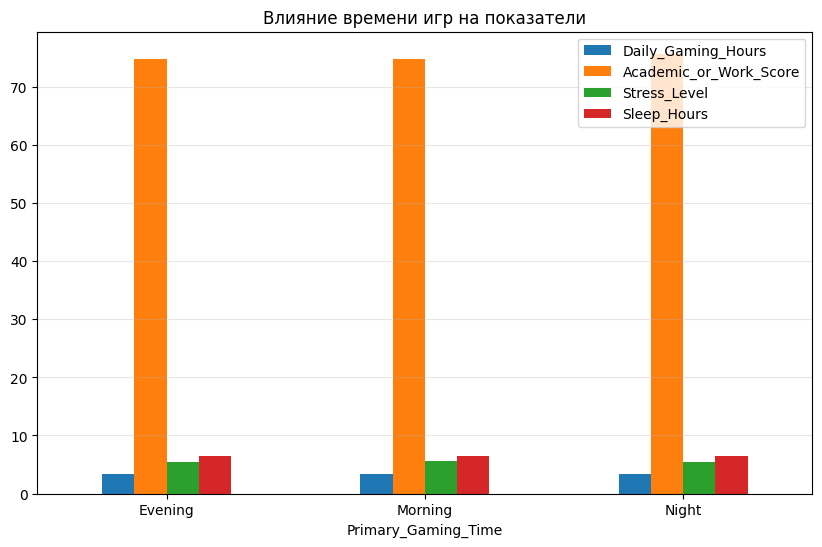

In [42]:
time_stats.plot(kind='bar', figsize=(10, 6))
plt.title('Влияние времени игр на показатели')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

Вывод: Ночные игроки демонстрируют наибольшее игровое время (3.38 ч/день) и одновременно самые высокие оценки продуктивности (75.72 баллов), что противоречит стереотипу о негативном влиянии ночных игр на успеваемость. Утренние и вечерние игроки показывают схожие, но несколько более низкие результаты.

## 4.4. Предпочтения по жанрам видеоигр

Распределение по жанрам:

In [ ]:
genre_counts = df['Game_Type'].value_counts()
print("Распределение по жанрам:")
print(genre_counts)

Распределение по жанрам:
Game_Type
Simulation    192
Action        180
Sports        161
Casual        160
Strategy      157
Puzzle        150
Name: count, dtype: int64
Всего уникальных жанров: 6


Визуализация распределения:

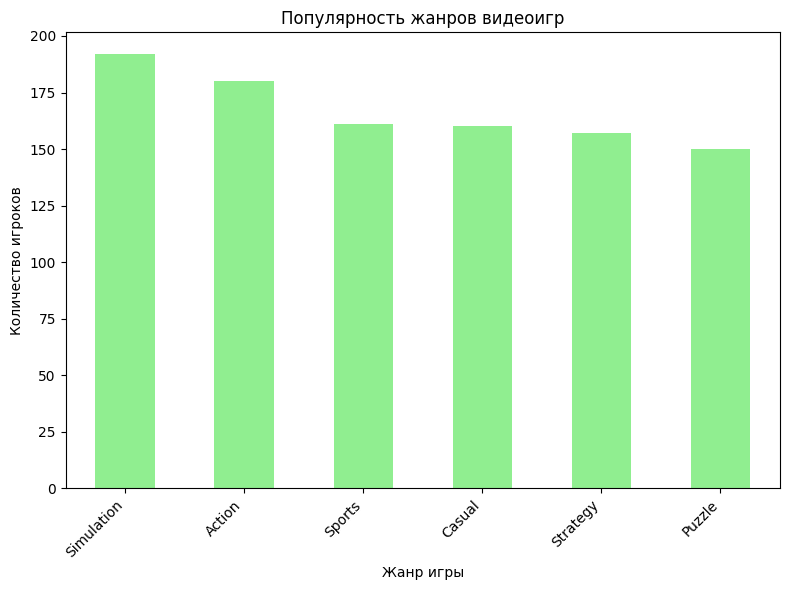

In [44]:
plt.figure(figsize=(8, 6))
genre_counts.plot(kind='bar', color='lightgreen')
plt.title('Популярность жанров видеоигр')
plt.xlabel('Жанр игры')
plt.ylabel('Количество игроков')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Связь жанра с показателями:

In [46]:
genre_stats = df.groupby('Game_Type').agg({
    'Daily_Gaming_Hours': 'mean',
    'Academic_or_Work_Score': 'mean', 
    'Stress_Level': 'mean',
    'Age': 'mean'
}).round(2)

print(genre_stats)

            Daily_Gaming_Hours  Academic_or_Work_Score  Stress_Level    Age
Game_Type                                                                  
Action                    3.34                   73.78          5.54  26.83
Casual                    3.52                   75.47          5.62  26.41
Puzzle                    3.47                   74.59          5.47  26.46
Simulation                3.34                   74.98          5.41  26.06
Sports                    3.26                   75.32          5.33  26.83
Strategy                  2.99                   76.50          5.35  27.08


Вывод: Игроки в стратегии демонстрируют наименьшее игровое время (2.99 ч/день) при максимальной успеваемости (76.50 баллов), в то время как любители казуальных игр играют больше всех (3.52 ч/день), сохраняя высокие показатели продуктивности (75.47 баллов). Игроки в экшн-игры имеют наиболее низкие оценки (73.78 баллов), что может указывать на различное влияние жанров на когнитивные функции.

## 4.5 Взаимосвязь демографических и поведенческих факторов

Жанры по полу:

In [47]:
pivot1 = pd.pivot_table(df, 
                       index='Game_Type',
                       columns='Gender', 
                       values='User_ID',
                       aggfunc='count',
                       fill_value=0)
print(pivot1)

Gender      Female  Male
Game_Type               
Action          80   100
Casual          95    65
Puzzle          85    65
Simulation      99    93
Sports          76    85
Strategy        78    79


Время игр по роду занятий:

In [48]:
pivot2 = pd.pivot_table(df,
                       index='Occupation',
                       columns='Primary_Gaming_Time',
                       values='Daily_Gaming_Hours',
                       aggfunc='mean',
                       fill_value=0)
print(pivot2.round(2))

Primary_Gaming_Time   Evening  Morning  Night
Occupation                                   
Student                  3.25     3.25   3.23
Working Professional     3.35     3.32   3.56


Пол + статус + оценки:

In [49]:
pivot3 = pd.pivot_table(df,
                       index='Gender',
                       columns='Occupation',
                       values='Academic_or_Work_Score',
                       aggfunc='mean')
print(pivot3.round(2))

Occupation  Student  Working Professional
Gender                                   
Female        75.78                 74.83
Male          75.10                 74.49


Вывод: Наиболее успешной группой являются студентки (75.78 баллов), предпочитающие казуальные и симуляционные игры. Работающие мужчины показывают наименьшую продуктивность (74.49 баллов) при наибольшем игровом времени в ночные часы (3.56 ч/день). Гендерные различия в предпочтениях жанров выражены ярко: женщины выбирают Casual и Simulation, мужчины - Action и Sports.

# 5. Заключение

## 5.1. Ключевые выводы исследования

1. Основной парадокс: Игровые привычки не оказывают статистически значимого влияния на академическую и рабочую продуктивность в исследуемой выборке.

2. Демографические инсайты:
- Студентки показывают наивысшую успеваемость (75.78 баллов)
- Работающие мужчины имеют наибольшее игровое время в ночные часы (3.56 ч/день)
- Жанровые предпочтения сильно зависят от пола

3. Неожиданные результаты:
- Ночные игроки демонстрируют лучшие оценки
- Игроки в стратегии имеют наименьшее игровое время при максимальной продуктивности
- Все предполагаемые негативные влияния не подтвердились